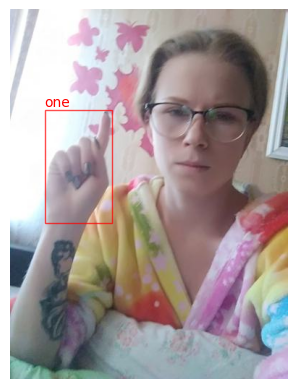

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import ast

row = pd.read_csv(r"yolo_dataset\df.csv")

row['bbox'] = row['bbox'].apply(ast.literal_eval)
row['label'] = row['label'].apply(ast.literal_eval)

random = np.random.randint(0, len(row))

path = row.iloc[random]['path']
bboxes = row.iloc[random]['bbox']
labels = row.iloc[random]['label']

fig, ax = plt.subplots()
img = plt.imread(path)
ax.imshow(img)

h_img, w_img = img.shape[:2]

for idx, box in enumerate(bboxes):
    x, y, w, h = box 
    
    x_px = x * w_img
    w_px = w * w_img
    y_px = y * h_img
    h_px = h * h_img
    
    rect = patches.Rectangle((x_px, y_px), w_px, h_px, facecolor='none', linewidth=1, edgecolor='red', alpha=0.7)
    ax.add_patch(rect)
    label = labels[idx]
    if label == "palm":
        label = "five"
    ax.text(x_px, y_px - 5, label, color='red')

plt.axis('off')
plt.show()